In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [60]:
#reading dataset
df_real = pd.read_csv('ford.csv')
df_real

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


In [61]:
#checking row and colums
df_real.shape

(17966, 9)

In [62]:
#checking null values
df_real.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [63]:
#checking duplicates
df_real.duplicated().sum()
df = df_real.drop_duplicates()

<Axes: xlabel='price', ylabel='Count'>

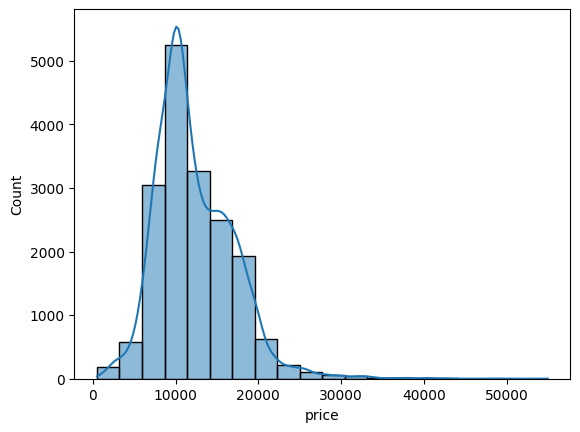

In [64]:
sns.histplot(df['price'],bins=20,kde=True)

<Axes: xlabel='fuelType', ylabel='count'>

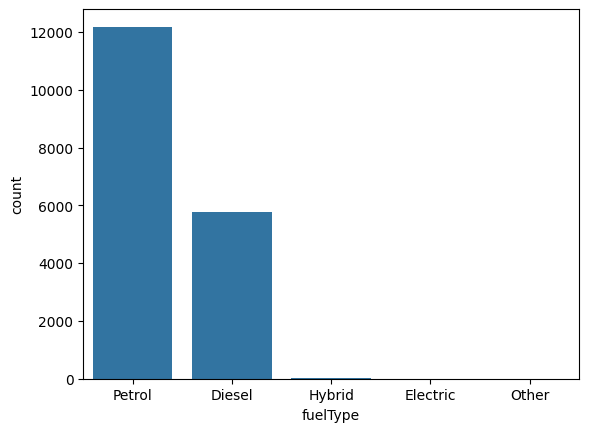

In [65]:
sns.countplot(x=df_real['fuelType'])

<Axes: xlabel='engineSize', ylabel='price'>

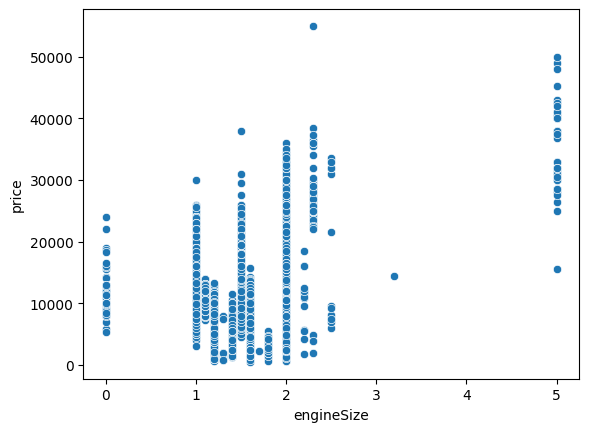

In [66]:
sns.scatterplot(x='engineSize',y='price',data=df)

<Axes: xlabel='mileage', ylabel='price'>

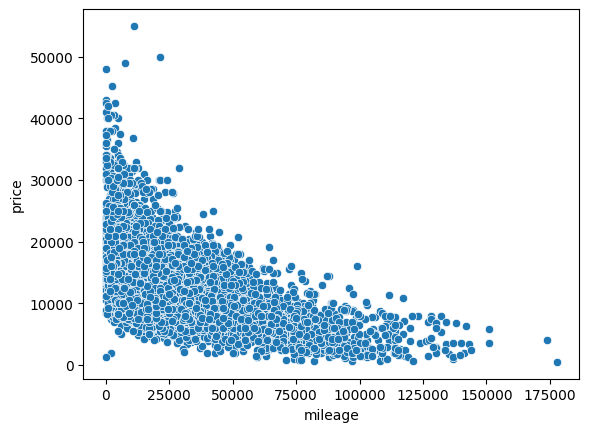

In [67]:
sns.scatterplot(x='mileage',y='price',data=df)

<Axes: xlabel='tax', ylabel='price'>

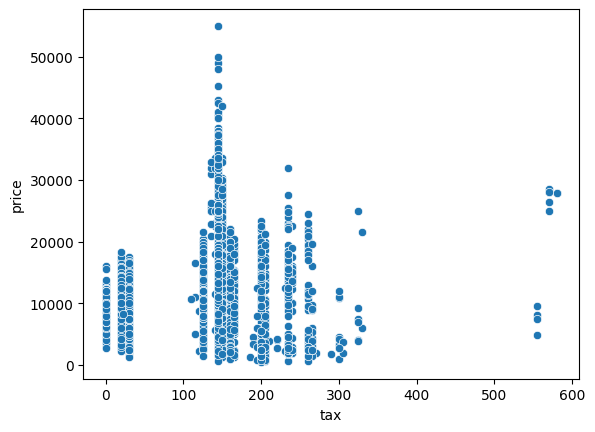

In [68]:
sns.scatterplot(x='tax',y='price',data=df)

<Axes: xlabel='year', ylabel='price'>

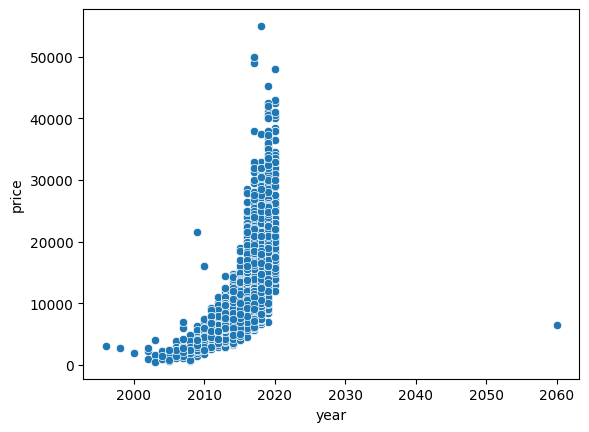

In [69]:
sns.scatterplot(x='year',y='price',data=df)

<Axes: xlabel='mpg', ylabel='price'>

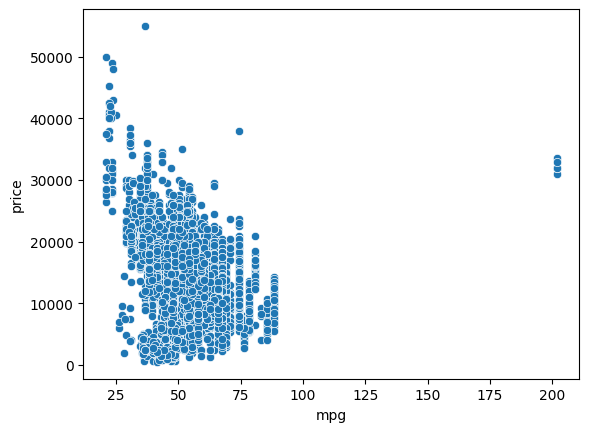

In [70]:
sns.scatterplot(x='mpg',y='price',data=df)

In [71]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='str')

<Axes: xlabel='transmission', ylabel='price'>

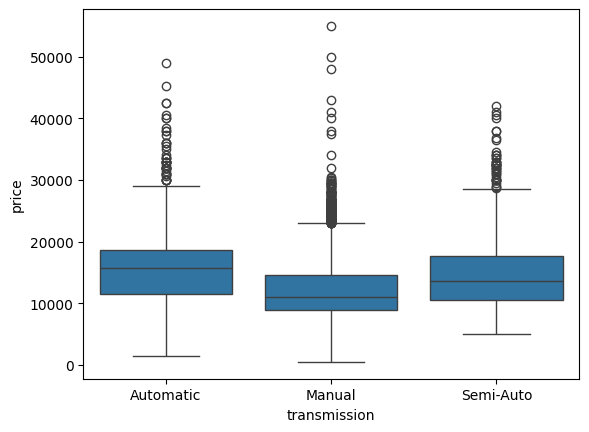

In [72]:
sns.boxplot(x='transmission', y='price', data=df)

<Axes: xlabel='fuelType', ylabel='price'>

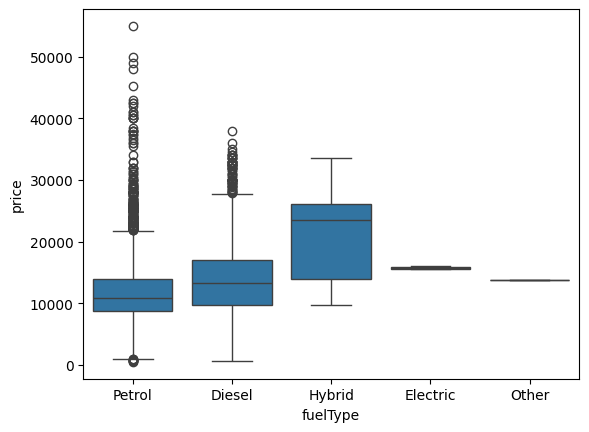

In [73]:
sns.boxplot(x='fuelType', y='price', data=df)

<Axes: xlabel='mileage', ylabel='Count'>

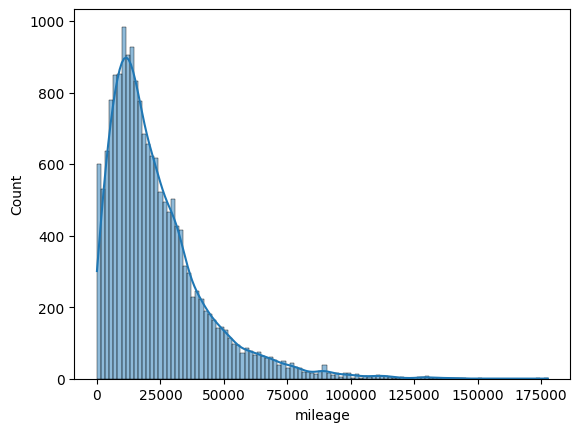

In [74]:
sns.histplot(df['mileage'], kde=True)

<Axes: >

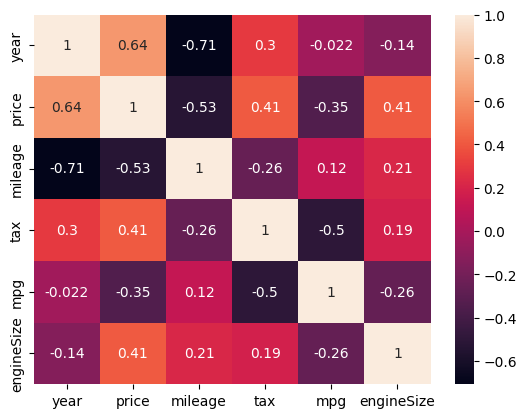

In [75]:
#heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

# Data Preprocessing


In [76]:
#one hot Encoding
df = pd.get_dummies(df,drop_first=True).astype(int)
df

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12000,15944,150,57,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2018,14000,9083,150,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,13000,12456,150,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,17500,10460,145,40,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,2019,16500,1482,145,48,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,8999,16700,150,47,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,2014,7499,40700,30,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,2015,9999,7010,20,67,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,2018,8299,5007,145,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [77]:
#standard scaler

In [78]:
df_real.columns
colums = ['engineSize','mpg','tax','mileage','year']

In [79]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[colums] =scaler.fit_transform(df[colums])
df


,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.067059,12000,-0.382994,0.591380,-0.042291,-0.446958,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0.554393,14000,-0.736317,0.591380,-0.042291,-0.446958,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.067059,13000,-0.562616,0.591380,-0.042291,-0.446958,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.041726,17500,-0.665405,0.510777,-1.720193,-0.446958,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,1.041726,16500,-1.127749,0.510777,-0.930592,-0.446958,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.067059,8999,-0.344061,0.591380,-1.029292,-0.446958,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,-1.394942,7499,0.891875,-1.343079,-0.042291,-0.446958,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,-0.907608,9999,-0.843071,-1.504284,0.944711,-0.446958,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,0.554393,8299,-0.946220,0.510777,-0.042291,-0.446958,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


# Feature Selection

In [80]:
# stats
from sklearn.feature_selection import mutual_info_regression
X = df.drop('price',axis=1)
y = df['price']

mi_score = mutual_info_regression(X,y)
mi_series= pd.Series(mi_score,index=X.columns)
mi_series.sort_values(ascending=False)

mpg                             0.513479
year                            0.504702
tax                             0.282121
mileage                         0.279250
engineSize                      0.132374
model_ Fiesta                   0.098665
model_ Kuga                     0.075243
fuelType_Petrol                 0.046391
transmission_Manual             0.035553
model_ Focus                    0.030230
model_ Ka+                      0.029127
model_ Edge                     0.024341
model_ KA                       0.022493
model_ Mustang                  0.019160
transmission_Semi-Auto          0.016484
model_ EcoSport                 0.014809
model_ Galaxy                   0.014473
model_ Puma                     0.013701
model_ C-MAX                    0.012227
model_ S-MAX                    0.010012
model_ Tourneo Custom           0.008630
fuelType_Hybrid                 0.008033
model_ Grand C-MAX              0.005328
model_ Mondeo                   0.004153
fuelType_Other  

In [81]:
df.columns

Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize', 'model_ C-MAX',
       'model_ EcoSport', 'model_ Edge', 'model_ Escort', 'model_ Fiesta',
       'model_ Focus', 'model_ Fusion', 'model_ Galaxy', 'model_ Grand C-MAX',
       'model_ Grand Tourneo Connect', 'model_ KA', 'model_ Ka+',
       'model_ Kuga', 'model_ Mondeo', 'model_ Mustang', 'model_ Puma',
       'model_ Ranger', 'model_ S-MAX', 'model_ Streetka',
       'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'transmission_Manual',
       'transmission_Semi-Auto', 'fuelType_Electric', 'fuelType_Hybrid',
       'fuelType_Other', 'fuelType_Petrol'],
      dtype='str')

In [82]:
col = ['year','mpg','mileage','tax','engineSize']
all= ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'model_ C-MAX',
       'model_ EcoSport', 'model_ Edge', 'model_ Escort', 'model_ Fiesta',
       'model_ Focus', 'model_ Fusion', 'model_ Galaxy', 'model_ Grand C-MAX',
       'model_ Grand Tourneo Connect', 'model_ KA', 'model_ Ka+',
       'model_ Kuga', 'model_ Mondeo', 'model_ Mustang', 'model_ Puma',
       'model_ Ranger', 'model_ S-MAX', 'model_ Streetka',
       'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'transmission_Manual',
       'transmission_Semi-Auto',
        'fuelType_Petrol']

#X=df.drop('price',axis=1)
X = df[all]
y=df['price']

In [83]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Linear Regression


In [84]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [85]:
y_predict = model.predict(X_test)


In [86]:
#model evaluation
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_predict)
r2


0.8258664879525599

In [87]:
#adjusted r
n = X_test.shape[0]
p= X_test.shape[1]
adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))
adjusted_r2

0.8244371440948255